In [1]:
#defining functions for later processing and feature enggimport pandas as pd
from itertools import product

#####
from sklearn.linear_model import LinearRegression
def create_lag(df, lag_sca, lag_dd, lag_precip, lag_et):
    df['sca_lagged'] = df['sca'].shift(lag_sca)
    df['dd_lagged'] = df['dd'].shift(lag_dd)
    df['et_loss_lagged'] = df['et_loss'].shift(lag_et)
    df['melt_proxy'] = df['sca_lagged']*df['dd_lagged']
    df['precipitation_lagged'] = df['precipitation'].shift(lag_precip)
    # df['precipitation_lagged-1'] = df['precipitation'].shift(lag_precip-1)
    # df['precipitation_lagged_cum'] = ((df['precipitation']+df['precipitation_lagged'])/2)
    
    df_clean = df.dropna()
    return df_clean

#####
import numpy as np
def calculate_nse(observed, predicted):
    mean_obs = np.mean(observed)
    numerator = np.sum((observed - predicted) ** 2)
    denominator = np.sum((observed - mean_obs) ** 2)
    return 1 - (numerator / denominator)

# Step 1 – Data Import & Exploration
Import the dataset and examine its structure, dimensions, data types, and data quality before any analysis.

In [2]:
# Cell 1 – Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import missingno as msno

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import xgboost as xgb
from sklearn.preprocessing import MinMaxScaler

import warnings
warnings.filterwarnings('ignore')

def rmse(predictions, targets):
    return np.sqrt(mean_squared_error(predictions, targets))

In [3]:
# Cell 2 – Load & Explore Dataset
import pandas as pd
df1 = pd.read_csv('final_data_physics_baseline/phy_final_corrected_data.csv')
pd.to_datetime(df1['date'])
df1 = df1.set_index('date')
df1.drop(columns= 'Unnamed: 0', inplace= True)
df1.drop(columns= 'Unnamed: 0.1', inplace= True)

# we convert 0-12 to radians circle for a seasonal mapping (circular time encoding)
# ensure index is treated as datetime (works even if the Index is not recognized as DatetimeIndex)
import numpy as np
month = pd.DatetimeIndex(df1.index).month

df1['year_sin'] = np.sin(2*np.pi*month/12)
df1['year_cos'] = np.cos(2*np.pi*month/12)


df = df1.copy()
df.head()


,dewpoint,et_loss,ndvi,precipitation,radiation,sca,dd,temp,runoff,year_sin,year_cos
date,,,,,,,,,,,
2000-06-30,270.274111,0.035384,0.167895,1.081265,8552.215167,15695.091988,5.271130,278.271130,0.959289,1.224647e-16,-1.000000e+00
2000-07-31,275.634907,0.005471,0.214835,2.074423,8945.476526,6188.434963,9.535170,282.535170,0.515886,-5.000000e-01,-8.660254e-01
2000-08-31,273.643363,0.016486,0.171795,1.208544,8787.250911,10114.130241,7.745643,280.745643,0.355015,-8.660254e-01,-5.000000e-01
2000-09-30,266.780844,0.040531,0.148384,0.857759,7687.016192,12888.810599,3.499669,276.499669,0.186357,-1.000000e+00,-1.836970e-16
2000-10-31,259.412862,0.029951,0.113129,0.231264,5685.865842,19583.623736,0.000000,268.727686,0.138155,-8.660254e-01,5.000000e-01


In [4]:
# Describe numerical columns
(df1.isnull())

,dewpoint,et_loss,ndvi,precipitation,radiation,sca,dd,temp,runoff,year_sin,year_cos
date,,,,,,,,,,,
2000-06-30,False,False,False,False,False,False,False,False,False,False,False
2000-07-31,False,False,False,False,False,False,False,False,False,False,False
2000-08-31,False,False,False,False,False,False,False,False,False,False,False
2000-09-30,False,False,False,False,False,False,False,False,False,False,False
2000-10-31,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
2025-07-31,False,False,False,False,False,False,False,False,False,False,False
2025-08-31,False,False,False,False,False,False,False,False,False,False,False
2025-09-30,False,False,False,False,False,False,False,False,False,False,False


# Step 2 – Visualise Missing Values

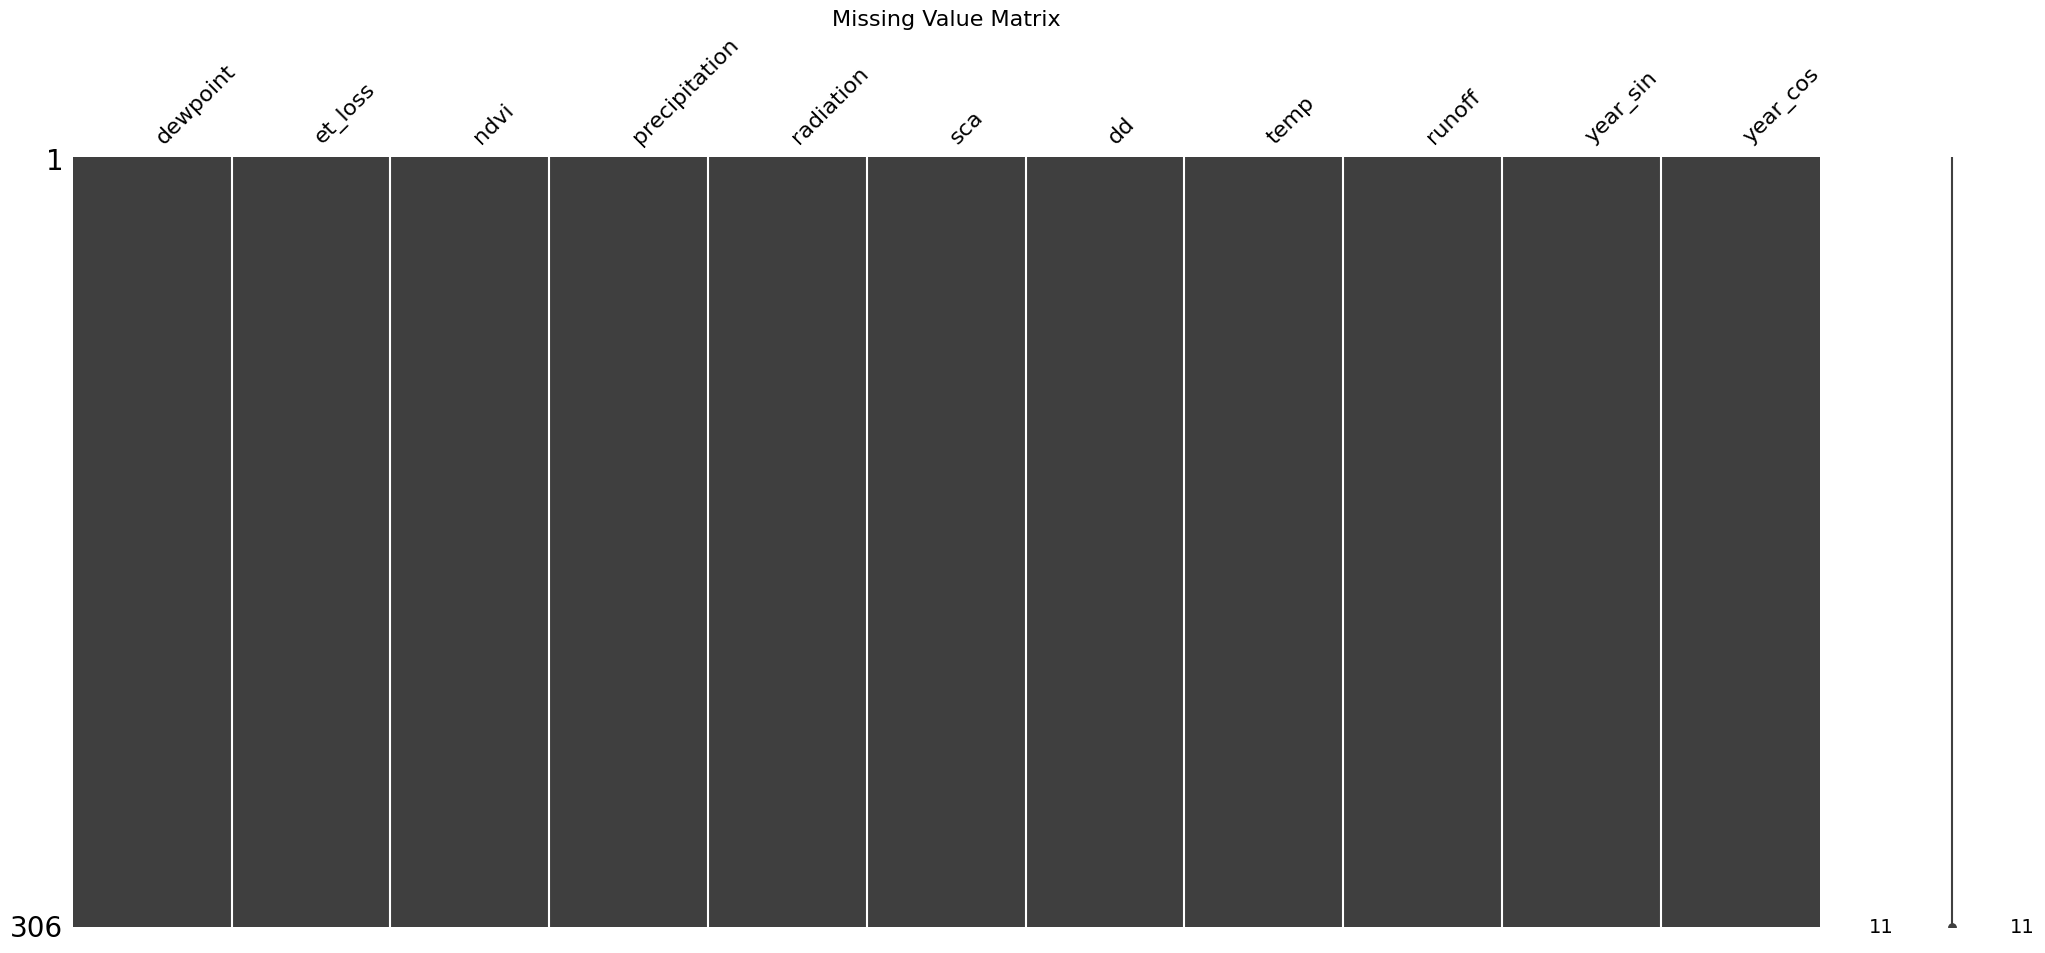

In [5]:
# Cell 3 – Missing Value Matrix
# Visualize missing values as a matrix
msno.matrix(df1)
plt.title('Missing Value Matrix', fontsize=16)
plt.show()

# Step 3 – Data Manipulation & Feature Engineering
Clean the dataset, drop unnecessary columns, fix data types, and create analysis-ready features.

In [6]:
# Cell 4 – Feature Engineering with Lagged Variables
def create_lag_adv_corrected(df_in):
    """
    Creates advanced lagged features WITHOUT data leakage.
    - Uses a copy to avoid modifying the original dataframe.
    - Enforces a minimum lag of 1 to prevent using current-day info.
    """
    df = df_in.copy() # Work on a copy to prevent side effects

    for i in range(1, 8):
        df[f'sca_lagged_{i}'] = df['sca'].shift(i)
        df[f'dd_lagged_{i}'] = df['dd'].shift(i)
    df['et_loss_lagged_1'] = df['et_loss'].shift(1)
    df['precipitation_lagged_1'] = df['precipitation'].shift(1)

    for i in range(1,8):
        for j in range(1,8):
            if i >= j and i - j < 2:
                df[f'melt_proxy_{i}_{j}'] = df[f'sca_lagged_{i}'] * df[f'dd_lagged_{j}']
    
    
    return df.dropna()


# Step 4 – Exploratory Data Analysis
Visualise distributions, correlations, and patterns to understand how features relate to the runoff target.

In [7]:
# Cell 5 - Time Series Plot of Runoff
px.line(df1, y='runoff', title='Monthly Runoff at Tarbela')

In [8]:
# Cell 6 - Plotting other key variables
fig = make_subplots(rows=3, cols=1, shared_xaxes=True, subplot_titles=('Precipitation', 'Temperature', 'Snow Covered Area (SCA)'))
fig.add_trace(go.Scatter(x=df.index, y=df['precipitation'], mode='lines', name='Precipitation'), row=1, col=1)
fig.add_trace(go.Scatter(x=df.index, y=df['temp'], mode='lines', name='Temperature'), row=2, col=1)
fig.add_trace(go.Scatter(x=df.index, y=df['sca'], mode='lines', name='SCA'), row=3, col=1)
fig.update_layout(height=600, title_text="Key Climate Variables Over Time")
fig.show()

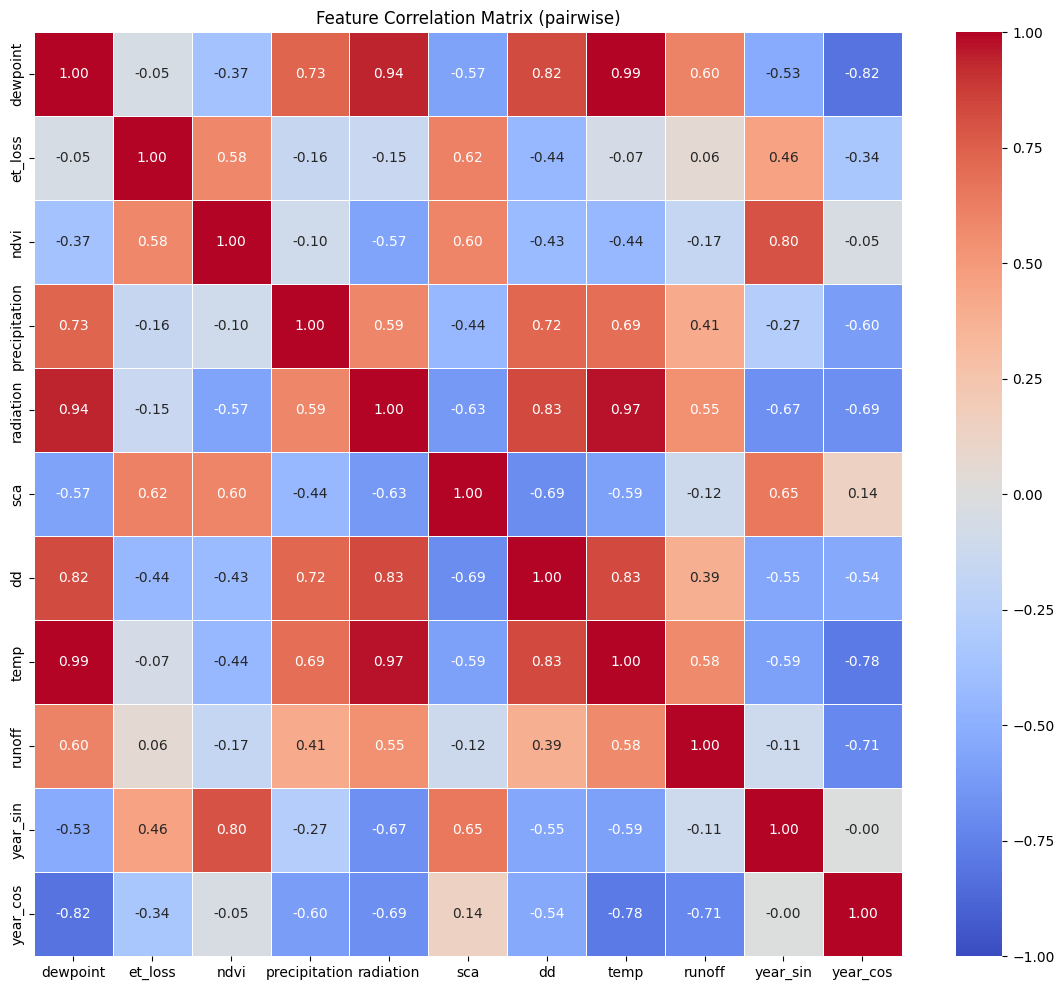

In [9]:
import numpy as np

# Cell 7 – Correlation Heatmap
plt.figure(figsize=(14, 12))
# full correlation matrix between all numeric features
corr = df.corr()

# mask the upper triangle for readability
# mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)
plt.title('Feature Correlation Matrix (pairwise)')
plt.show()

# Step 5 – Data Preprocessing & Baseline Model

In [10]:
# Cell 8 – Train-Validation-Test Split
#train baseline prediction regression model only fitted on train data
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# --- FIX: Prevent data leakage by splitting BEFORE creating lagged features ---

# 1. Split the raw dataframe first
train_raw = df[:'2017-12-31']
val_raw = df['2018-01-01':'2021-12-31']
test_raw = df['2022-01-01':]

# 2. Apply the lag function to each split independently
x_train = create_lag(train_raw, lag_precip=1, lag_dd=1, lag_sca=1, lag_et=1)
x_val = create_lag(val_raw, lag_precip=1, lag_dd=1, lag_sca=1, lag_et=1)
x_test = create_lag(test_raw, lag_precip=1, lag_dd=1, lag_sca=1, lag_et=1)

# 3. Create feature and target sets from the leakage-free dataframes
X_train_lagged = x_train[['sca_lagged','dd_lagged','year_sin', 'year_cos', 'melt_proxy', 'et_loss_lagged', 'precipitation_lagged']]
Y_train_lagged = x_train[['runoff']]

X_val_lagged = x_val[['sca_lagged','dd_lagged','year_sin', 'year_cos', 'melt_proxy', 'et_loss_lagged', 'precipitation_lagged']]
Y_val_lagged = x_val[['runoff']]

X_test_lagged = x_test[['sca_lagged','dd_lagged','year_sin', 'year_cos', 'melt_proxy', 'et_loss_lagged', 'precipitation_lagged']]
Y_test_lagged = x_test[['runoff']]

X_train_val = pd.concat([X_train_lagged, X_val_lagged])
Y_train_val = pd.concat([Y_train_lagged, Y_val_lagged])

Baseline NSE: runoff    0.720984
dtype: float64
Linear Regression Coefficients:
[[ 1.43796502e-05 -1.52598982e-01 -8.75474964e-01 -1.07899964e+00
  -3.16604590e-06 -7.03119169e+00 -2.81540821e-02]]
Linear Regression R-squared: 0.7210


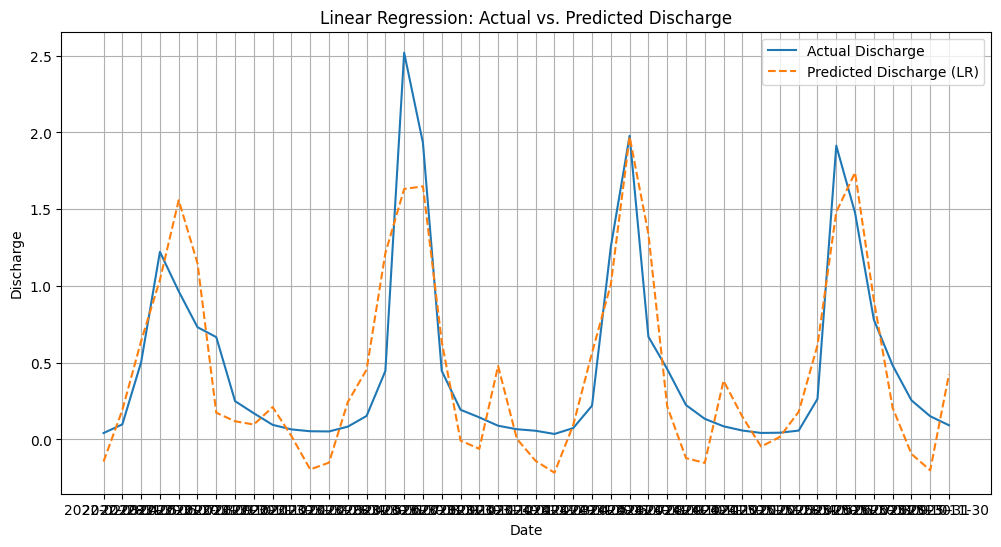

In [11]:
from sklearn.metrics import r2_score

# Cell 9 - Linear Regression Model
# Define features (X) and target (y)
seasonaware_model = LinearRegression()
seasonaware_model.fit(X_train_lagged, Y_train_lagged)

y_test_pred = seasonaware_model.predict(X_test_lagged)
baseline_nse = calculate_nse(Y_test_lagged, y_test_pred)
print(f"Baseline NSE: {baseline_nse}")

print("Linear Regression Coefficients:")
print(seasonaware_model.coef_)

# Evaluate the model
r2_lr = r2_score(Y_test_lagged.values.ravel(), y_test_pred.ravel())
print(f'Linear Regression R-squared: {r2_lr:.4f}')

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(x_test.index, Y_test_lagged, label='Actual Discharge')
plt.plot(x_test.index, y_test_pred, label='Predicted Discharge (LR)', linestyle='--')
plt.title('Linear Regression: Actual vs. Predicted Discharge')
plt.xlabel('Date')
plt.ylabel('Discharge')
plt.legend()
plt.grid(True)
plt.show()

Baseline NSE: runoff    0.40445
dtype: float64
Linear Regression Coefficients:
[[ 8.23037920e-06 -2.09024089e-02  1.19274407e+01  2.30922612e-01]]
Linear Regression R-squared: 0.4044


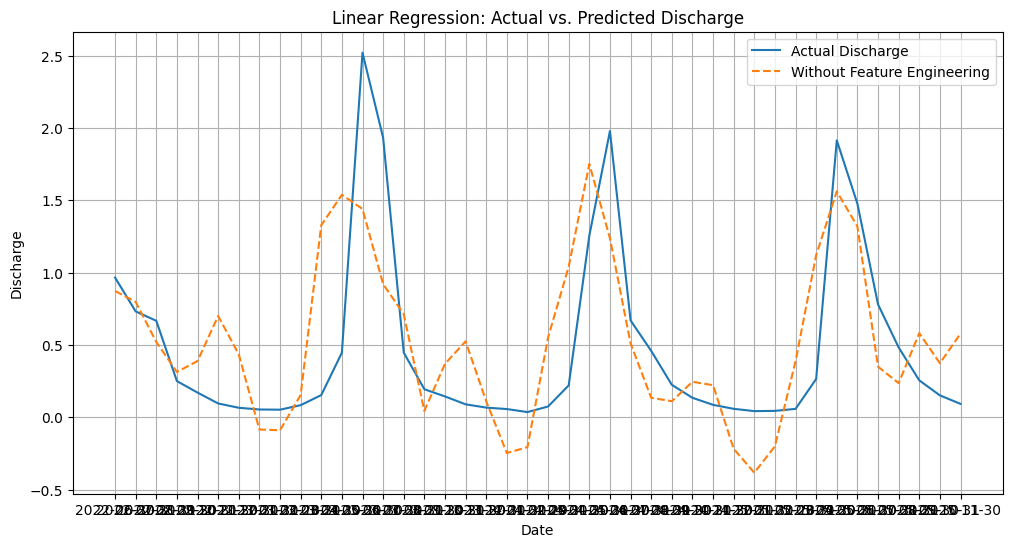

Baseline NSE: runoff    0.505248
dtype: float64
Linear Regression Coefficients:
[[ 1.37590952e-05 -7.94701653e-02  1.31080318e+01  2.52911382e-01]]
Linear Regression R-squared: 0.5052


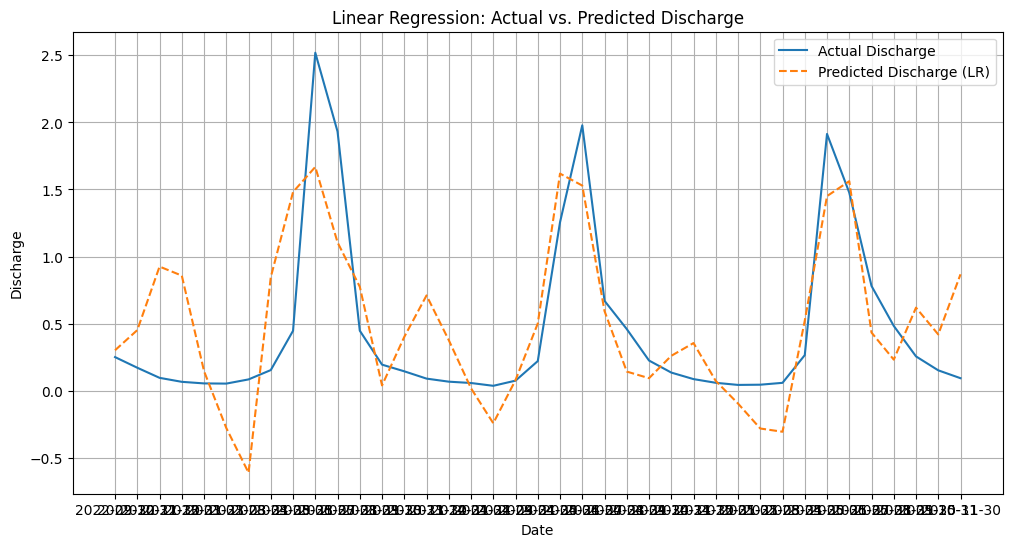

In [12]:
# Cell 8 – Train-Validation-Test Split (variables renamed, original names preserved for compatibility)

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# new variable names
raw_train_df = df[:'2017-12-31']
raw_val_df   = df['2018-01-01':'2021-12-31']
raw_test_df  = df['2022-01-01':]

lag_train_df = create_lag(raw_train_df, lag_precip=1, lag_dd=5, lag_sca=1, lag_et=1)
lag_val_df   = create_lag(raw_val_df,   lag_precip=1, lag_dd=5, lag_sca=1, lag_et=1)
lag_test_df  = create_lag(raw_test_df,  lag_precip=1, lag_dd=5, lag_sca=1, lag_et=1)

X_tr_lagged = lag_train_df[['sca_lagged','dd_lagged', 'et_loss_lagged', 'precipitation_lagged']]
y_tr_lagged = lag_train_df[['runoff']]

X_val_lagged = lag_val_df[['sca_lagged','dd_lagged', 'et_loss_lagged', 'precipitation_lagged']]
y_val_lagged = lag_val_df[['runoff']]

X_te_lagged = lag_test_df[['sca_lagged','dd_lagged', 'et_loss_lagged', 'precipitation_lagged']]
y_te_lagged = lag_test_df[['runoff']]

X_tr_val_comb = pd.concat([X_tr_lagged, X_val_lagged])
y_tr_val_comb = pd.concat([y_tr_lagged, y_val_lagged])

# renamed model variable
baseline_lr_model = LinearRegression()
baseline_lr_model.fit(X_tr_lagged, y_tr_lagged)

y_te_pred_new = baseline_lr_model.predict(X_te_lagged)
baseline_nse_new = calculate_nse(y_te_lagged, y_te_pred_new)
print(f"Baseline NSE: {baseline_nse_new}")

print("Linear Regression Coefficients:")
print(baseline_lr_model.coef_)

r2_baseline = r2_score(y_te_lagged.values.ravel(), y_te_pred_new.ravel())
print(f'Linear Regression R-squared: {r2_baseline:.4f}')

plt.figure(figsize=(12, 6))
plt.plot(lag_test_df.index, y_te_lagged, label='Actual Discharge')
plt.plot(lag_test_df.index, y_te_pred_new, label='Without Feature Engineering', linestyle='--')

plt.title('Linear Regression: Actual vs. Predicted Discharge')
plt.xlabel('Date')
plt.ylabel('Discharge')
plt.legend()
plt.grid(True)
plt.show()


from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# new variable names
raw_train_df = df[:'2017-12-31']
raw_val_df   = df['2018-01-01':'2021-12-31']
raw_test_df  = df['2022-01-01':]

lag_train_df = create_lag(raw_train_df, lag_precip=1, lag_dd=8, lag_sca=1, lag_et=1)
lag_val_df   = create_lag(raw_val_df,   lag_precip=1, lag_dd=8, lag_sca=1, lag_et=1)
lag_test_df  = create_lag(raw_test_df,  lag_precip=1, lag_dd=8, lag_sca=1, lag_et=1)

X_tr_lagged = lag_train_df[['sca_lagged','dd_lagged', 'et_loss_lagged', 'precipitation_lagged']]
y_tr_lagged = lag_train_df[['runoff']]

X_val_lagged = lag_val_df[['sca_lagged','dd_lagged', 'et_loss_lagged', 'precipitation_lagged']]
y_val_lagged = lag_val_df[['runoff']]

X_te_lagged = lag_test_df[['sca_lagged','dd_lagged', 'et_loss_lagged', 'precipitation_lagged']]
y_te_lagged = lag_test_df[['runoff']]

X_tr_val_comb = pd.concat([X_tr_lagged, X_val_lagged])
y_tr_val_comb = pd.concat([y_tr_lagged, y_val_lagged])

# renamed model variable
baseline_lr_model = LinearRegression()
baseline_lr_model.fit(X_tr_lagged, y_tr_lagged)

y_te_pred_new = baseline_lr_model.predict(X_te_lagged)
baseline_nse_new = calculate_nse(y_te_lagged, y_te_pred_new)
print(f"Baseline NSE: {baseline_nse_new}")

print("Linear Regression Coefficients:")
print(baseline_lr_model.coef_)

r2_baseline = r2_score(y_te_lagged.values.ravel(), y_te_pred_new.ravel())
print(f'Linear Regression R-squared: {r2_baseline:.4f}')

plt.figure(figsize=(12, 6))
plt.plot(lag_test_df.index, y_te_lagged, label='Actual Discharge')
plt.plot(lag_test_df.index, y_te_pred_new, label='Predicted Discharge (LR)', linestyle='--')

plt.title('Linear Regression: Actual vs. Predicted Discharge')
plt.xlabel('Date')
plt.ylabel('Discharge')
plt.legend()
plt.grid(True)
plt.show()

In [13]:
# --- FIX: Create a clean, leakage-free dataframe for the hybrid model ---

# 1. Get baseline predictions for each split
train_preds = seasonaware_model.predict(X_train_lagged)
val_preds = seasonaware_model.predict(X_val_lagged)
test_preds = seasonaware_model.predict(X_test_lagged)

# 2. Combine baseline predictions and residuals into a single dataframe
baseline_results = pd.concat([
    pd.DataFrame({'baseline_q': train_preds.ravel(), 'runoff': Y_train_lagged.runoff}, index=X_train_lagged.index),
    pd.DataFrame({'baseline_q': val_preds.ravel(), 'runoff': Y_val_lagged.runoff}, index=X_val_lagged.index),
    pd.DataFrame({'baseline_q': test_preds.ravel(), 'runoff': Y_test_lagged.runoff}, index=X_test_lagged.index)
])
baseline_results['residuals'] = baseline_results['runoff'] - baseline_results['baseline_q']

# 3. Create advanced lagged features on the original raw data (no leakage yet)
df_adv_features = create_lag_adv_corrected(df1)

# 4. Join the baseline results with the advanced features
# This aligns everything by date index before the final split
df_adv = df_adv_features.join(baseline_results[['baseline_q', 'residuals']]).dropna()

# Add seasonal features back in
# df_adv['year_sin'] = df1['year_sin']
# df_adv['year_cos'] = df1['year_cos']
df_adv.dropna(inplace=True)

df_adv.head()

ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- melt_proxy
- year_cos
- year_sin


In [14]:

# df_adv = create_lag_adv_corrected(df1) 
# df_adv = df_adv.join(df_full[['baseline_q', 'residuals']]).dropna()
# df_adv.head()
# df_adv['year_sin'] = x_lagged['year_sin']
# df_adv['year_cos'] = x_lagged['year_cos']
col_names = df_adv.columns.tolist()
col_names

NameError: name 'df_adv' is not defined

# Step 6 – Train Hybrid Models
Train more advanced models on the residuals of the baseline model.

In [15]:
# Cell 10 - XGBoost Model Data Preparation

import pandas as pd

# --- FIX: Dynamically define features from the corrected df_adv to prevent leakage ---

# 1. Define target and baseline columns to be excluded from features
target_and_baseline_cols = ['runoff', 'baseline_q', 'residuals','ndvi', 'dewpoint', 'dd','temp','sca','precipitation', 'year_cos', 'year_sin', 'radiation','et_loss',]
feature_columns = [col for col in df_adv.columns if col not in target_and_baseline_cols]

# 2. Split the fully prepared and leakage-free dataframe
train_ml = df_adv[:'2017-12-31']
val_ml = df_adv['2018-01-01':'2021-12-31']
test_ml = df_adv['2022-01-01':]

# 3. Prepare features (X) and labels (y) for the hybrid model
X_train_ml = train_ml[feature_columns]
y_train_ml = train_ml['residuals']

X_val_ml = val_ml[feature_columns]
y_val_ml = val_ml['residuals']

X_test_ml = test_ml[feature_columns]
y_test_ml = test_ml['residuals']

# Display the first few rows of the training features to verify
X_train_ml.head()


NameError: name 'df_adv' is not defined

In [16]:
from sklearn.model_selection import GridSearchCV
import xgboost as xgb

# Define the parameter grid
# You can expand this grid to tune other parameters as well
param_grid = {
    'max_depth': [3, 4, 5, 6, 7],
    'n_estimators': range(500,1100, 100),
    'learning_rate': [0.01, 0.1, 0.2]
}

# Initialize the XGBoost regressor
xgb_reg = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# Initialize GridSearchCV
# We use 'neg_root_mean_squared_error' as the scoring metric.
# GridSearchCV maximizes the score, so it minimizes RMSE.
grid_search = GridSearchCV(estimator=xgb_reg, param_grid=param_grid, 
                           cv=3, n_jobs=-1, verbose=2, scoring='neg_root_mean_squared_error')

# Fit GridSearchCV
# Note: This can take some time to run
grid_search.fit(X_train_ml, y_train_ml)

# Print the best parameters found
print(f"Best parameters found: {grid_search.best_params_}")

# You can now use the best estimator for prediction
best_xgb_model = grid_search.best_estimator_



NameError: name 'X_train_ml' is not defined

In [17]:
# --- Now proceed with the corrected dataframe ---
from sklearn.metrics import r2_score
from xgboost import XGBRegressor

# --- Try a simpler XGBoost model ---
xgb2 = XGBRegressor(
    max_depth=3,
    learning_rate=0.01, # Slightly higher learning rate
    n_estimators=500,   # Fewer estimators
    random_state=42
)

# 3. Fit the model ONLY on the training data
xgb2.fit(X_train_ml, y_train_ml)

# 4. Predict on the validation set
residual_pred_val = xgb2.predict(X_val_ml)
q_hybrid_val = residual_pred_val + val_ml['baseline_q']

# 5. Evaluate against the correct validation ground truth
y_val_true = val_ml['runoff']
hybrid_nse_val = calculate_nse(y_val_true, q_hybrid_val)

print(f"Corrected Hybrid NSE (Validation): {hybrid_nse_val:.4f}")

# --- Final Test Set Evaluation ---
# Prepare combined training/validation data
X_train_val_ml = pd.concat([X_train_ml, X_val_ml])
y_train_val_ml = pd.concat([y_train_ml, y_val_ml])

# Prepare test data
X_test_ml = test_ml.drop(columns=target_and_baseline_cols)

# Re-fit the model on all available training data
xgb2.fit(X_train_val_ml, y_train_val_ml)

# Predict on the test set
residual_pred_test = xgb2.predict(X_test_ml)
q_hybrid_test = residual_pred_test + test_ml['baseline_q']

# Evaluate against the test ground truth
y_test_true = test_ml['runoff']
hybrid_nse_test = calculate_nse(y_test_true, q_hybrid_test)

print(f"Final Hybrid NSE (Test): {hybrid_nse_test:.4f}")

# Compute R² for validation and test hybrid predictions
r2_val = r2_score(y_val_true, q_hybrid_val)
r2_test = r2_score(y_test_true, q_hybrid_test)

print(f'Validation R² (Hybrid XGB): {r2_val:.4f}')
print(f'Test R² (Hybrid XGB):       {r2_test:.4f}')
# Plot Validation and Test: Observed vs Baseline vs Hybrid
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=False)

# Validation plot
axes[0].plot(val_ml.index, df.loc[val_ml.index, 'runoff'], label='Observed (Val)', color='black', linewidth=2)
axes[0].plot(val_ml.index, val_ml['baseline_q'], label='Baseline (Val)', linestyle='--', alpha=0.8)
axes[0].plot(val_ml.index, q_hybrid_val, label='Hybrid XGB (Val)', linestyle='-.', alpha=0.9)
axes[0].set_title(f'Validation: Observed vs Baseline vs Hybrid  |  NSE (Hybrid) = {hybrid_nse_val:.3f}')
axes[0].set_ylabel('Runoff')
axes[0].legend()
axes[0].grid(True)

# Test plot
axes[1].plot(test_ml.index, df.loc[test_ml.index, 'runoff'], label='Observed (Test)', color='black', linewidth=2)
axes[1].plot(test_ml.index, test_ml['baseline_q'], label='Baseline (Test)', linestyle='--', alpha=0.8)
axes[1].plot(test_ml.index, q_hybrid_test, label='Hybrid XGB (Test)', linestyle='-.', alpha=0.9)
axes[1].set_title(f'Test: Observed vs Baseline vs Hybrid  |  NSE (Hybrid) = {hybrid_nse_test:.3f}')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Runoff')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

NameError: name 'X_train_ml' is not defined

NameError: name 'test_ml' is not defined

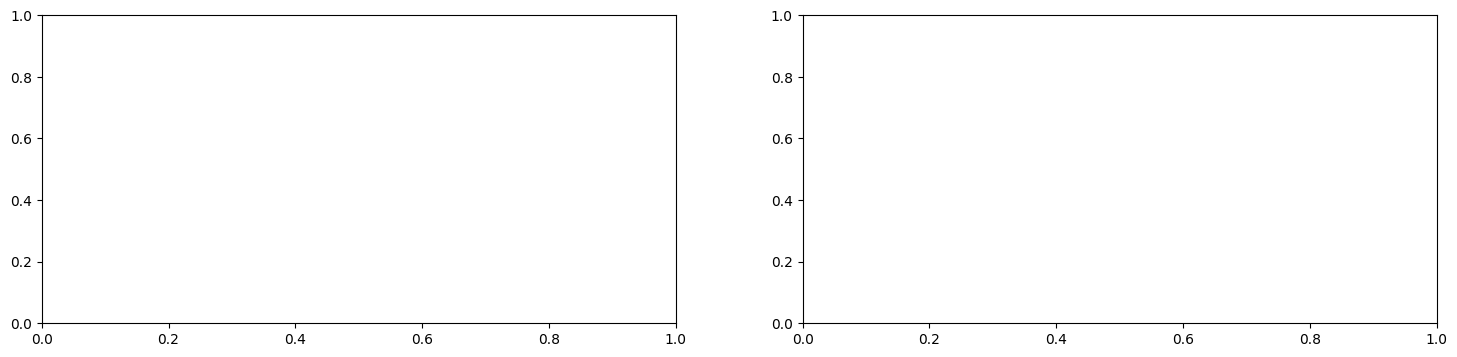

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.stattools import durbin_watson

fig, axes = plt.subplots(1,2, figsize= (18, 4))
# plot_acf( residual_pred_valf, lags = 12, ax = axes[0], title = 'val_acf' )
plot_acf( test_ml['residuals'], lags = 12, ax = axes[1], title = 'test_acf' )
plot_acf(residual_pred_test, lags=12, ax=axes[0], title='baseline_acf')

plt.savefig('acf_residuals.png', dpi=150)
plt.show()

# 2. Durbin-Watson statistic (quick scalar check)
dw_baseline = durbin_watson(test_ml['residuals'])
dw_hybrid   = durbin_watson(residual_pred_test)

print(f"Durbin-Watson — Baseline: {dw_baseline:.3f} | Hybrid: {dw_hybrid:.3f}")
# ~2.0 = no autocorrelation, <1.5 = positive autocorrelation (bad), >2.5 = negative


# Step 7 – Evaluate & Visualise Results
Compare performance across models and visualise the predictions against the observed data.

In [19]:
# Cell 13 - Create a results DataFrame for plotting (use actual names from this notebook)
# Observed: y_test_true (test ground truth)
# Baseline: y_test_pred (baseline LR predictions on X_test_lagged) -> flatten and align index
# Hybrid_XGB: q_hybrid_test (final hybrid XGB predictions on test)

baseline_series = pd.Series(y_test_pred.ravel(), index=y_test_true.index, name='Baseline')
xgb_series = pd.Series(q_hybrid_test, index=y_test_true.index, name='Hybrid_XGB')
lstm_series = pd.Series(np.nan, index=y_test_true.index, name='Hybrid_LSTM')

results_df = pd.DataFrame({
    'Observed': y_test_true,
    'Baseline': baseline_series,
    'Hybrid_XGB': xgb_series,
}, index=y_test_true.index)

# Plot the results
fig = go.Figure()
fig.add_trace(go.Scatter(x=results_df.index, y=results_df['Observed'], mode='lines', name='Observed Discharge', line=dict(width=8)))
fig.add_trace(go.Scatter(x=results_df.index, y=results_df['Baseline'], mode='lines', name='Baseline Model', line=dict(dash='dash', width=2)))
fig.add_trace(go.Scatter(x=results_df.index, y=results_df['Hybrid_XGB'], mode='lines', name='Hybrid XGBoost Model'))

fig.update_layout(title='Model Prediction Performance on Test Data',
                  xaxis_title='Date',
                  yaxis_title='Discharge (m³/s)',
                  legend_title='Models')
fig.show()

NameError: name 'y_test_true' is not defined

In [20]:
# Cell 14 - Feature Importance from XGBoost
plt.figure(figsize=(10, 12))
xgb.plot_importance(xgb2, max_num_features=20, height=0.8)
plt.title('XGBoost Feature Importance')
plt.show()

NotFittedError: need to call fit or load_model beforehand

<Figure size 1000x1200 with 0 Axes>